# IT Applications Assignment  
## Market Segmentation in the Global Video Game Industry using Unsupervised Machine Learning

**Student:** Boda Pooja  
**Section:** B  
**Roll Number:** IPM06091  
**Course:** IT Applications  
**Instructor:** Dr. Karan Verma

---

### Project Overview
This project analyzes the global video game industry using unsupervised machine learning techniques. The goal is to identify hidden market segments based on regional sales patterns and game characteristics using PCA and K-Means clustering.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

## Dataset Description

The dataset used in this project contains global video game sales information. It includes various attributes related to games, platforms, genres, publishers, and regional sales performance.

### Key Variables

- **Name** – Name of the video game  
- **Platform** – Gaming platform (PlayStation, Xbox, Nintendo etc.)  
- **Genre** – Category of the game  
- **Publisher** – Company that published the game  
- **NA_Sales** – Sales in North America  
- **EU_Sales** – Sales in Europe  
- **JP_Sales** – Sales in Japan  
- **Global_Sales** – Total worldwide sales

This dataset allows us to analyze global market patterns and understand how different regions contribute to game success.

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

Saving vgsales.csv to vgsales (1).csv


In [4]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (16324, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,Asteroids,2600,1980,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
1,545,Missile Command,2600,1980,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
2,1768,Kaboom!,2600,1980,Misc,Activision,1.07,0.07,0.0,0.01,1.15
3,1971,Defender,2600,1980,Misc,Atari,0.99,0.05,0.0,0.01,1.05
4,2671,Boxing,2600,1980,Fighting,Activision,0.72,0.04,0.0,0.01,0.77


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16324 entries, 0 to 16323
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16324 non-null  int64  
 1   Name          16324 non-null  object 
 2   Platform      16324 non-null  object 
 3   Year          16324 non-null  int64  
 4   Genre         16324 non-null  object 
 5   Publisher     16288 non-null  object 
 6   NA_Sales      16324 non-null  float64
 7   EU_Sales      16324 non-null  float64
 8   JP_Sales      16324 non-null  float64
 9   Other_Sales   16324 non-null  float64
 10  Global_Sales  16324 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [6]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,36
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [7]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000
mean,8291.508270,2006.404251,0.265464,0.147581,0.078673,0.048334,0.540328
std,4792.043734,5.826744,0.821658,0.508809,0.311584,0.189902,1.565860
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4135.750000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8293.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.250000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2016.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## Data Exploration

Before applying machine learning algorithms, we explore the dataset to understand patterns in the video game market.

This includes:

- analyzing genre distribution
- comparing platform performance
- understanding regional sales differences
- identifying correlations between sales variables

These insights help guide the machine learning analysis.

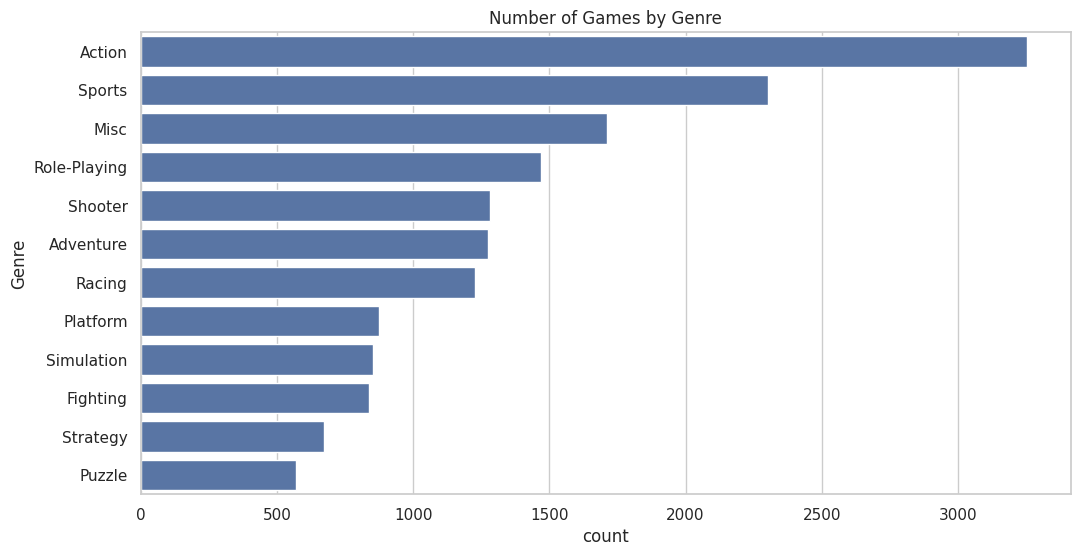

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y="Genre", order=df["Genre"].value_counts().index)
plt.title("Number of Games by Genre")
plt.show()

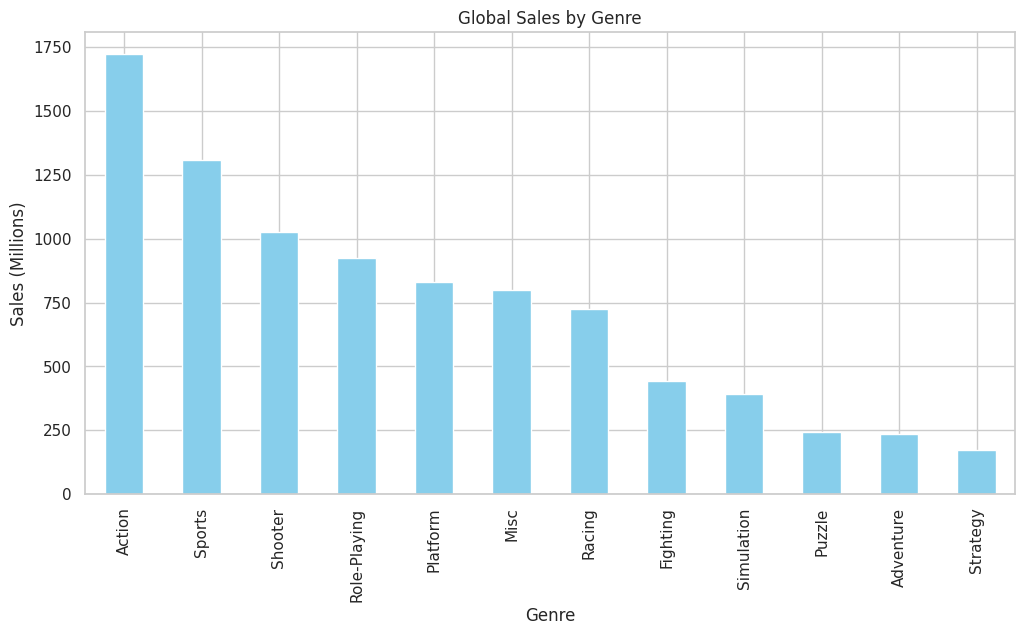

In [9]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_sales.plot(kind="bar", color="skyblue")
plt.title("Global Sales by Genre")
plt.ylabel("Sales (Millions)")
plt.show()

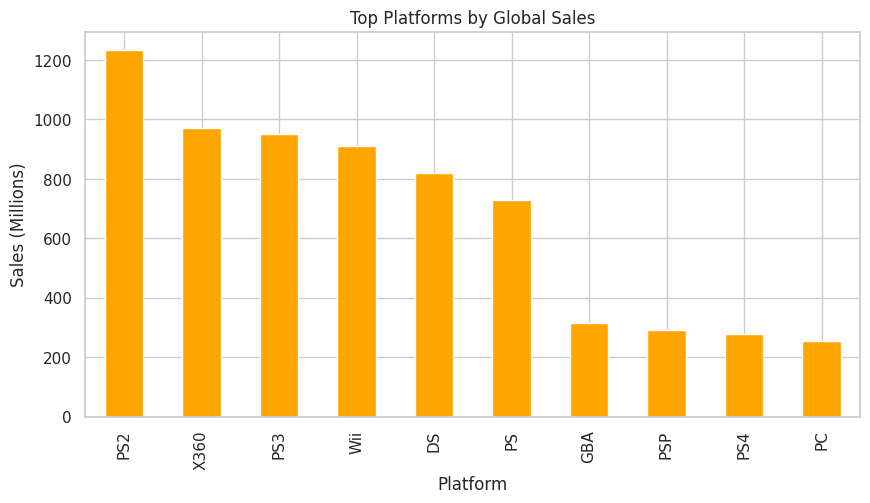

In [10]:
platform_sales = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
platform_sales.plot(kind="bar", color="orange")
plt.title("Top Platforms by Global Sales")
plt.ylabel("Sales (Millions)")
plt.show()

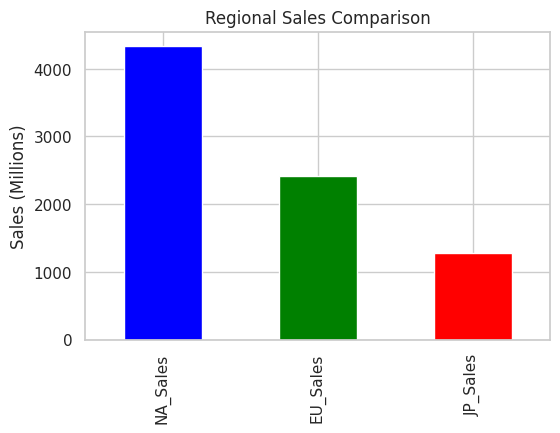

In [11]:
regions = ['NA_Sales','EU_Sales','JP_Sales']

region_totals = df[regions].sum()

plt.figure(figsize=(6,4))
region_totals.plot(kind="bar", color=['blue','green','red'])
plt.title("Regional Sales Comparison")
plt.ylabel("Sales (Millions)")
plt.show()

In [12]:
features = df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']]
features.head()

,NA_Sales,EU_Sales,JP_Sales,Global_Sales
0,4.00,0.26,0.0,4.31
1,2.56,0.17,0.0,2.76
2,1.07,0.07,0.0,1.15
3,0.99,0.05,0.0,1.05
4,0.72,0.04,0.0,0.77


In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset while preserving important information.

The dataset contains multiple correlated sales variables across different regions. PCA transforms these variables into principal components that capture the most significant patterns in the data.

This step helps simplify the dataset before applying clustering algorithms.

In [14]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])
pca_df.head()

,PC1,PC2
0,3.747786,-1.766191
1,2.183668,-1.140734
2,0.556087,-0.489178
3,0.449078,-0.444844
4,0.166561,-0.332222


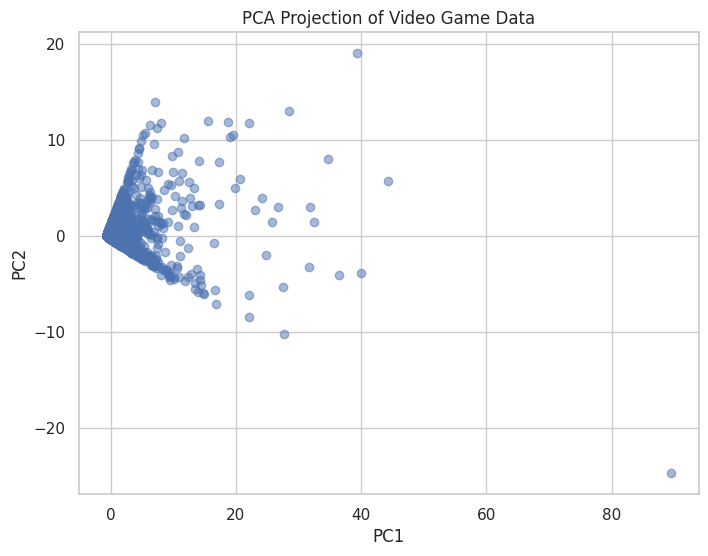

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.title("PCA Projection of Video Game Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Market Segmentation using K-Means Clustering

K-Means clustering is used to group video games into clusters based on similar sales patterns.

The algorithm identifies natural groupings within the dataset without predefined labels. This helps reveal hidden market segments within the global gaming industry.

By clustering games based on regional sales performance, we can identify different types of market behavior.

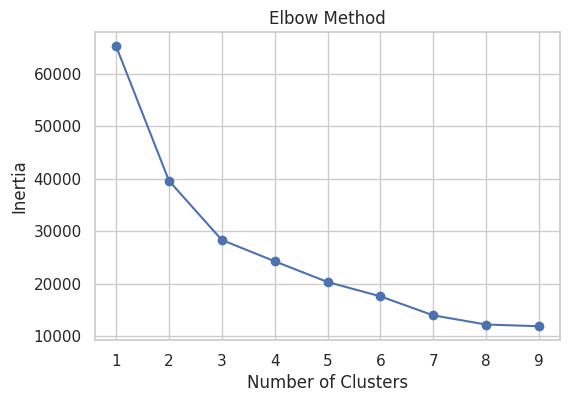

In [16]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

pca_df["Cluster"] = clusters

## Results and Cluster Analysis

After applying PCA and K-Means clustering, the dataset is segmented into different clusters representing distinct market patterns.

These clusters highlight differences in regional demand and game performance across global markets.

Visualization of the clusters helps interpret how games are distributed across these market segments.

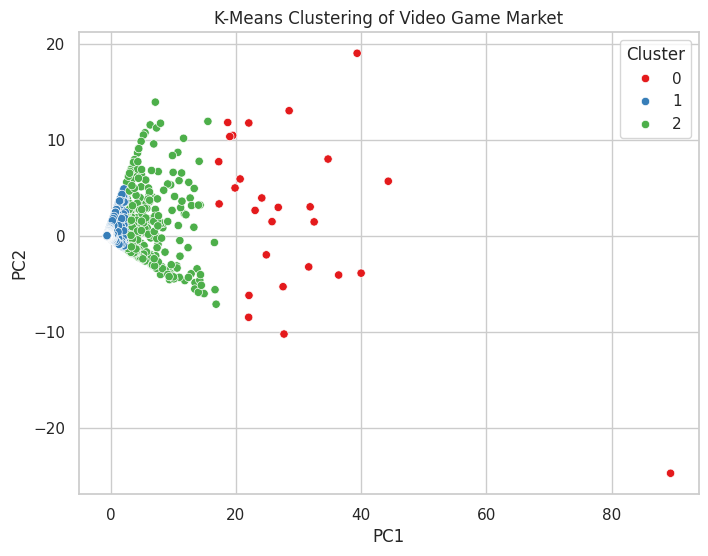

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1")
plt.title("K-Means Clustering of Video Game Market")
plt.show()

In [19]:
df["Cluster"] = clusters

cluster_summary = df.groupby("Cluster")[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']].mean()

cluster_summary

,NA_Sales,EU_Sales,JP_Sales,Global_Sales
Cluster,,,,
0,12.663333,7.209259,4.172963,25.877037
1,0.178481,0.090294,0.051638,0.352000
2,2.297495,1.544207,0.697515,5.019491


In [20]:
score = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.853859392917986


### Cluster Interpretation

Cluster 0 → Games with moderate sales across regions  
Cluster 1 → High global blockbuster games  
Cluster 2 → Region-specific niche games

This segmentation reveals hidden patterns in the global video game market.


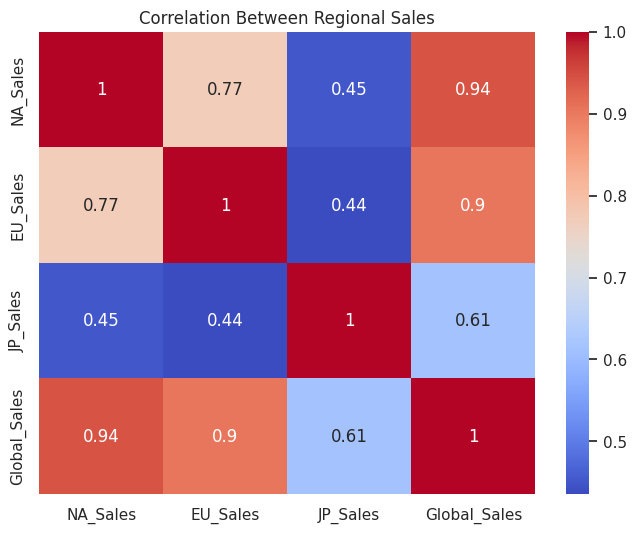

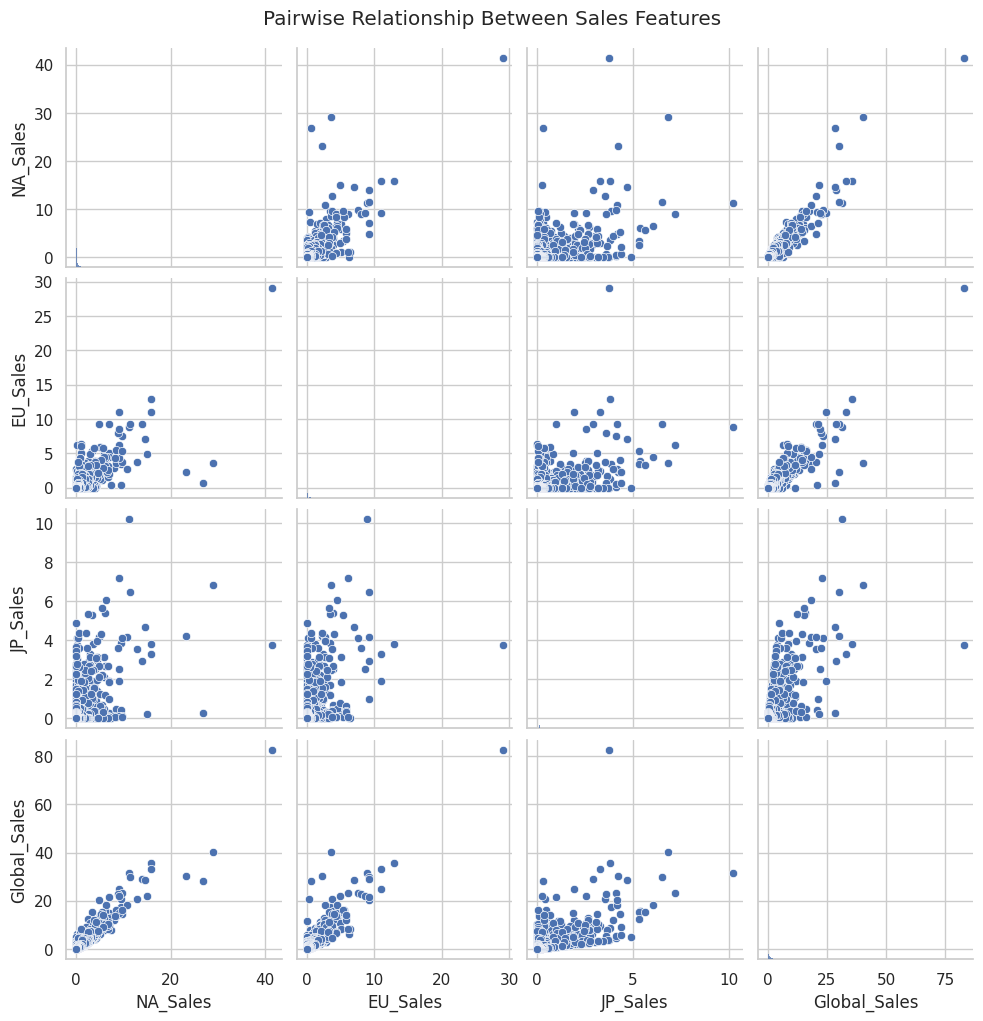

/tmp/ipykernel_167/1848722858.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Cluster", data=df, palette="Set2")


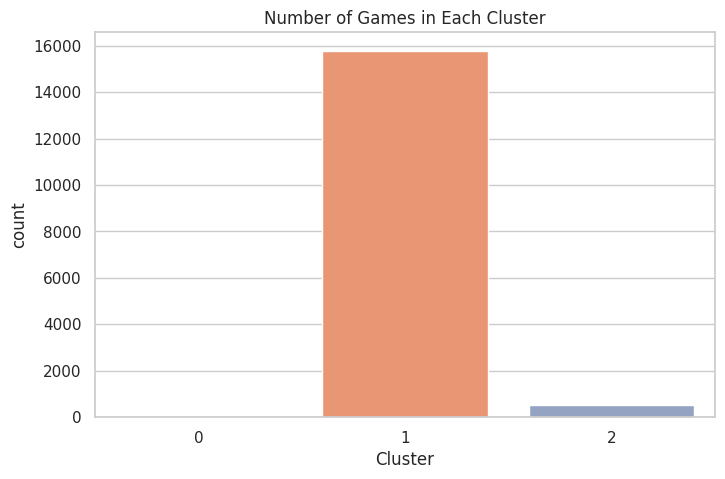

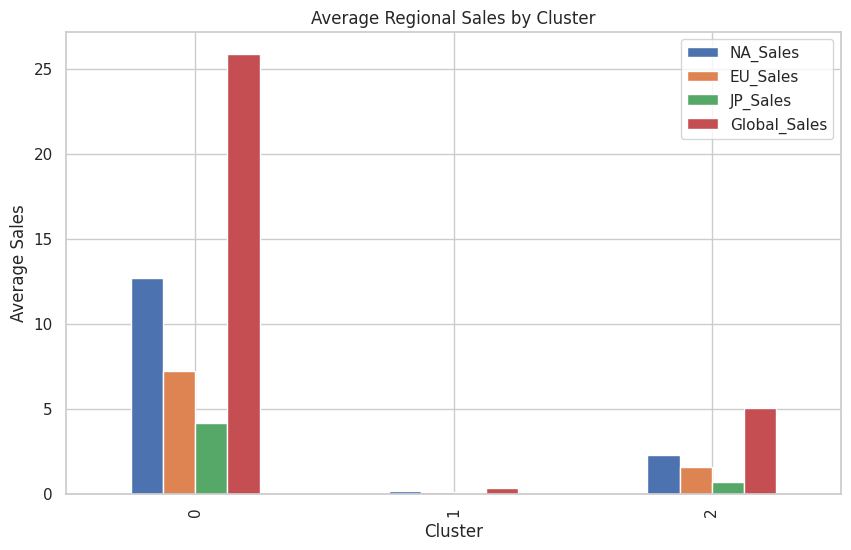

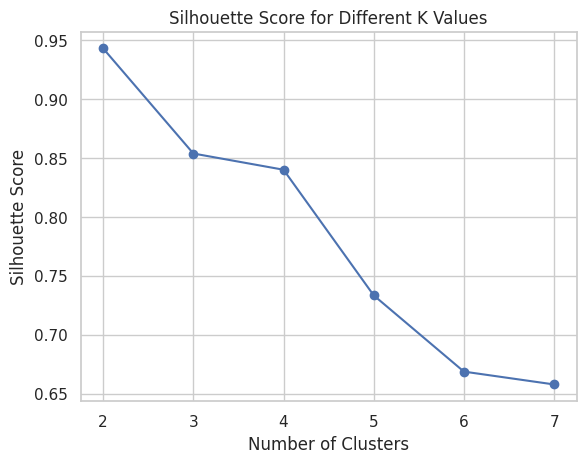

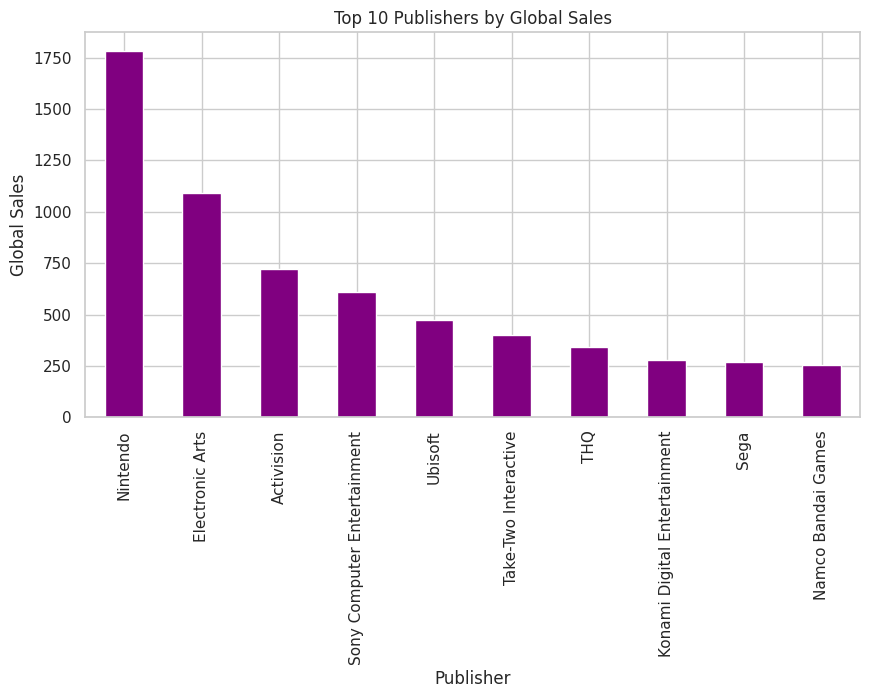

In [23]:
# -------------------------------
# CORRELATION ANALYSIS
# -------------------------------

plt.figure(figsize=(8,6))
sns.heatmap(df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Between Regional Sales")
plt.show()


# -------------------------------
# FEATURE RELATIONSHIPS
# -------------------------------

sns.pairplot(df[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']])
plt.suptitle("Pairwise Relationship Between Sales Features", y=1.02)
plt.show()


# -------------------------------
# CLUSTER DISTRIBUTION
# -------------------------------

plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=df, palette="Set2")
plt.title("Number of Games in Each Cluster")
plt.show()


# -------------------------------
# CLUSTER COMPARISON
# -------------------------------

cluster_means = df.groupby("Cluster")[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']].mean()

cluster_means.plot(kind='bar', figsize=(10,6))
plt.title("Average Regional Sales by Cluster")
plt.ylabel("Average Sales")
plt.show()


# -------------------------------
# SILHOUETTE SCORE COMPARISON
# -------------------------------

scores = []

for k in range(2,8):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    scores.append(score)

plt.plot(range(2,8), scores, marker='o')
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()


# -------------------------------
# TOP PUBLISHERS ANALYSIS
# -------------------------------

top_publishers = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_publishers.plot(kind="bar", color="purple")
plt.title("Top 10 Publishers by Global Sales")
plt.ylabel("Global Sales")
plt.show()

## Conclusion

This project applied unsupervised machine learning techniques to analyze patterns in the global video game market.

Using PCA and K-Means clustering, the analysis identified hidden market segments based on regional sales patterns.

The results demonstrate how machine learning can reveal insights about genre popularity, regional demand differences, and publisher strategies in the gaming industry.

These insights can support better decision-making for game developers and publishers.
